In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
df = pd.read_csv('Pb_labeled.csv')


GRtiming = df['GRQ2timing']
LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

In [2]:
xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

tracking_gated=df[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

# proton_gated=tracking_gated[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
# ]

# xdp_proton=proton_gated['GRX']
# adp_proton=proton_gated['GRA']
# ydp_proton=proton_gated['GRY']
# bdp_proton=proton_gated['GRB']
# GRQ2_proton=proton_gated['GRQ2charge']

#合わせる時は、GRQ2_trackとTOTを抽出してから
gated_208Pb = df[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]
gated_208Pb_GRQ2timing = gated_208Pb['GRQ2timing']
gated_208Pb_LASQ1timing = gated_208Pb['LASQ1timing']

# mean = 84.98
# sigma = 17.718

mean = 86.947
sigma = 3.377

#true coincidenceのみ抽出
TDiff = gated_208Pb_LASQ1timing - gated_208Pb_GRQ2timing
true_208Pb = gated_208Pb[
    (TDiff >= mean - 6 * sigma) & (TDiff <= mean + 7 * sigma)
]

true_208Pb_GRQ2timing = true_208Pb['GRQ2timing']
true_208Pb_LASQ1timing = true_208Pb['LASQ1timing']

In [3]:
true_208Pb_LASQ1timing

77         191083.0
107        460640.0
365        231979.0
682        216094.0
837         63277.8
             ...   
2238056     83271.1
2238642    189161.0
2238666    107425.0
2238713     89873.8
2238787    295200.0
Name: LASQ1timing, Length: 19914, dtype: float64

Text(0, 0.5, 'counts')

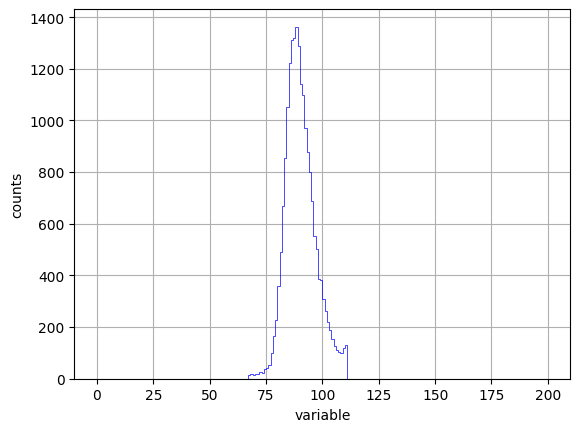

In [4]:
TDiff = true_208Pb_LASQ1timing - true_208Pb_GRQ2timing



#input
####################################################
#variables
variable=TDiff
#hist range
range_min=0
range_max=200
#bin width
x_bin_width = 1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

In [5]:
#　トラッキングできた、コインシデンスとったやつのみ抽出
GRX_gated = true_208Pb['GRX']
LASX_gated = true_208Pb['LASX']

Tp = []
for n in GRX_gated:
    Tp.append((((n * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27)

T_alpha = []
for n in LASX_gated:
    T_alpha.append(0.0274600000 * n + 63.8040000000)

Text(0, 0.5, 'counts')

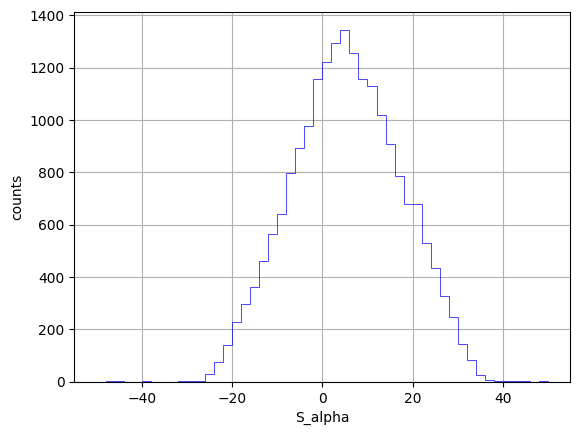

In [6]:
# リスト内包表記で各要素を足し算
S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha)]

variables = S_alpha

#hist range
range_min=-50
range_max=50
#bin width
x_bin_width=2

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')